In The Name Of God

Input LIbrary

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical

                     Get Data from Database

In [3]:
(X_train, y_train), (X_test, y_test)  = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


👀👀👀👀👀👀

In [4]:
X_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

Dimension of Input

In [5]:
X_train.shape

(60000, 28, 28)

Reshaping for CNN Input

In [6]:
X_train_plus = np.expand_dims(X_train, axis = -1 ) / 255

In [7]:
X_test_plus = np.expand_dims(X_test, axis = -1 ) / 255

In [8]:
X_train_plus.shape

(60000, 28, 28, 1)

ONE-HOT

In [9]:
Y_train_plus = to_categorical(y_train, 10)
Y_test_plus = to_categorical(y_test, 10)

Y_train_plus

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

Middle Layer

In [10]:
CNN = Sequential()

CNN.add(Conv2D(filters = 12, kernel_size = (3, 3), activation= 'relu', input_shape = (28, 28, 1)))
CNN.add(Conv2D(filters = 16, kernel_size = (3, 3), activation= 'relu'))
CNN.add(MaxPooling2D(pool_size=(2,2)))
CNN.add(Flatten())
CNN.add(Dense(16, activation = 'relu'))
CNN.add(Dense(10, activation = 'softmax'))

CNN.compile(loss= "categorical_crossentropy", optimizer = "adam" ,metrics = ["accuracy"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SUmmary We dont have any freezed Item

In [11]:
CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 12)          │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 16)          │           1,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │          36,880 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             170 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,914 (152.01 KB)

 Trainable params: 38,914 (152.01 KB)

 Non-trainable params: 0 (0.00 B)

Learn Model

In [12]:
cm = CNN.fit(X_train_plus,Y_train_plus, batch_size= 128, epochs = 20, validation_data=(X_test_plus,Y_test_plus),shuffle =True)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7848 - loss: 0.7493 - val_accuracy: 0.9566 - val_loss: 0.1472
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9665 - loss: 0.1159 - val_accuracy: 0.9771 - val_loss: 0.0743
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9789 - loss: 0.0763 - val_accuracy: 0.9797 - val_loss: 0.0650
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9813 - loss: 0.0620 - val_accuracy: 0.9833 - val_loss: 0.0546
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9859 - loss: 0.0481 - val_accuracy: 0.9839 - val_loss: 0.0485
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9879 - loss: 0.0401 - val_accuracy: 0.9837 - val_loss: 0.0472
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9888 - loss: 0.0366 - val_accuracy: 0.9870 - val_loss: 0.0440
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9918 - loss: 0.0276 - val_accuracy: 0

PLOT

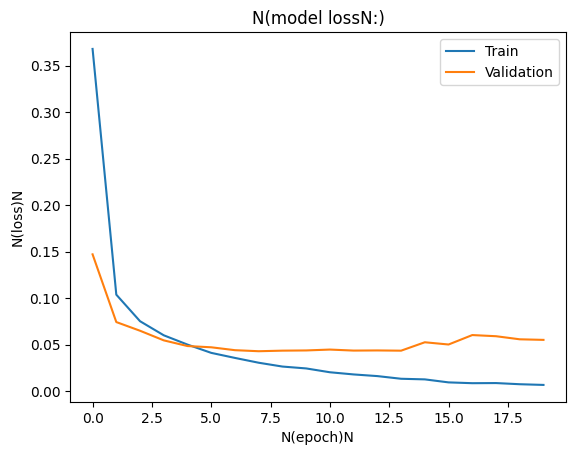

In [13]:
plt.plot(cm.history['loss'])
plt.plot(cm.history['val_loss'])
plt.title('N(model lossN:)')
plt.xlabel("N(epoch)N")
plt.ylabel("N(loss)N")
plt.legend(["Train" ,"Validation"] ,loc = "upper right")
plt.show()

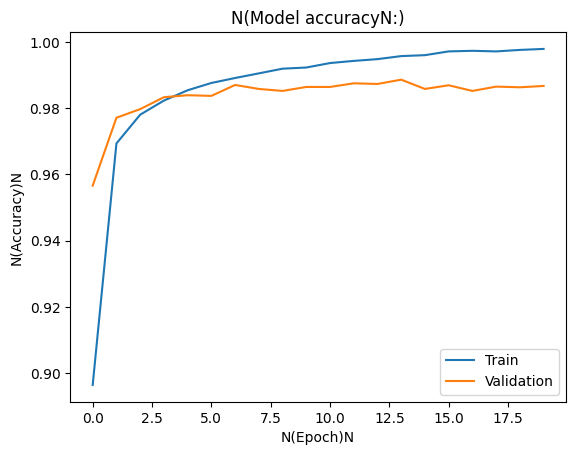

In [14]:
plt.plot(cm.history['accuracy'])
plt.plot(cm.history['val_accuracy'])
plt.title('N(Model accuracyN:)')
plt.ylabel('N(Accuracy)N')
plt.xlabel('N(Epoch)N')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()


**Predict** AND MAX OF ROW

In [15]:
yp = np.argmax(CNN.predict(X_test_plus), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [16]:
from sklearn.metrics import confusion_matrix ,classification_report
cm = confusion_matrix(y_test, np.argmax(CNN.predict(X_test_plus), axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [17]:
cm

array([[ 973,    0,    1,    1,    0,    0,    4,    0,    1,    0],
       [   0, 1125,    2,    2,    0,    0,    1,    1,    4,    0],
       [   1,    1, 1019,    0,    1,    0,    1,    5,    4,    0],
       [   0,    0,    3, 1001,    0,    4,    0,    0,    2,    0],
       [   0,    0,    0,    0,  975,    0,    2,    0,    1,    4],
       [   1,    0,    1,    5,    0,  882,    2,    0,    1,    0],
       [   4,    3,    0,    1,    1,    2,  944,    0,    3,    0],
       [   0,    1,   12,    0,    1,    0,    0, 1010,    1,    3],
       [   5,    0,    1,    4,    1,    0,    1,    1,  959,    2],
       [   2,    0,    0,    3,    7,    6,    0,    4,    8,  979]])

export Data to excel

In [18]:
import pandas as pd
cmmm = pd.DataFrame(cm)
cmmm.to_csv('cm.csv')

In [19]:
print(classification_report(y_test, yp))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.97      0.98      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [20]:
ddmm=print(classification_report(y_test, yp))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.97      0.98      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



                     **GUTTEN** **ABEND**